In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
N_SEGS = 6
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# Source
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5    


params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, qS, phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, qS_i, phiS_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))
        except Exception:
            pass
    return out


def prior_transform(u):
    logm1lim = [5.92138, 6.11220]
    logm2lim = [0.89200, 1.01955]
    alim = [0.69030, 0.77933]
    p0lim = [8.00000, 9.45620]
    e0lim = [0.39955, 0.44961]
    qSlim = [0.0, np.pi]
    phiSlim = [0.0, 2 * np.pi]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.92138, 6.11220]
    logm2lim = [0.89200, 1.01955]
    alim = [0.69030, 0.77933]
    p0lim = [8.00000, 9.45620]
    e0lim = [0.39955, 0.44961]
    qSlim = [0.0, np.pi]
    phiSlim = [0.0, 2 * np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u



Using dt=5s, T=1.0yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/stage2_merge'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.now_covariances

[array([[ 2.72619294e-01,  3.13592480e-02, -1.61256748e-03,
         -1.28600993e-02, -7.61399306e-03, -8.33185133e-03,
         -2.28079601e-03],
        [ 3.13592480e-02,  3.25179305e-01, -9.64075618e-04,
          9.02103756e-03, -2.52047190e-03, -2.06015751e-02,
          7.96161563e-03],
        [-1.61256748e-03, -9.64075618e-04,  3.26948028e-01,
          2.27594458e-02,  2.98862399e-03,  2.35629440e-02,
         -1.09700856e-02],
        [-1.28600993e-02,  9.02103756e-03,  2.27594458e-02,
          2.70000461e-01, -1.42395888e-03,  8.31546974e-03,
          6.07080551e-03],
        [-7.61399306e-03, -2.52047190e-03,  2.98862399e-03,
         -1.42395888e-03,  2.32182590e-01, -3.61204165e-03,
          3.35403681e-05],
        [-8.33185133e-03, -2.06015751e-02,  2.35629440e-02,
          8.31546974e-03, -3.61204165e-03,  2.91258860e-01,
         -1.75420216e-02],
        [-2.28079601e-03,  7.96161563e-03, -1.09700856e-02,
          6.07080551e-03,  3.35403681e-05, -1.75420216e-02

In [5]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.00642793, 0.99997911, 0.71484013, 8.93267973, 0.40074913,
        0.01632843, 3.50714766]])

In [6]:
log_density(maxld_pt1)

array([20.98347147])

In [7]:
log_density([param_true])

array([28.53035408])

In [9]:
param_ranges = [(5.92138, 6.11220),
                (0.89200, 1.01955),
                (0.69030, 0.77933),
                (8.00000, 9.45620),
                (0.39955, 0.44961),
                (0.0, np.pi),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(5.92138, 6.1122),
 (0.892, 1.01955),
 (0.6903, 0.77933),
 (8.0, 9.4562),
 (0.39955, 0.44961),
 (0.0, 3.141592653589793),
 (0.0, 6.283185307179586)]

In [10]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,qS,phiS]
param_true

[6.0, 1.0, 0.7, 9, 0.4, 3.141592653589793, 0.0]

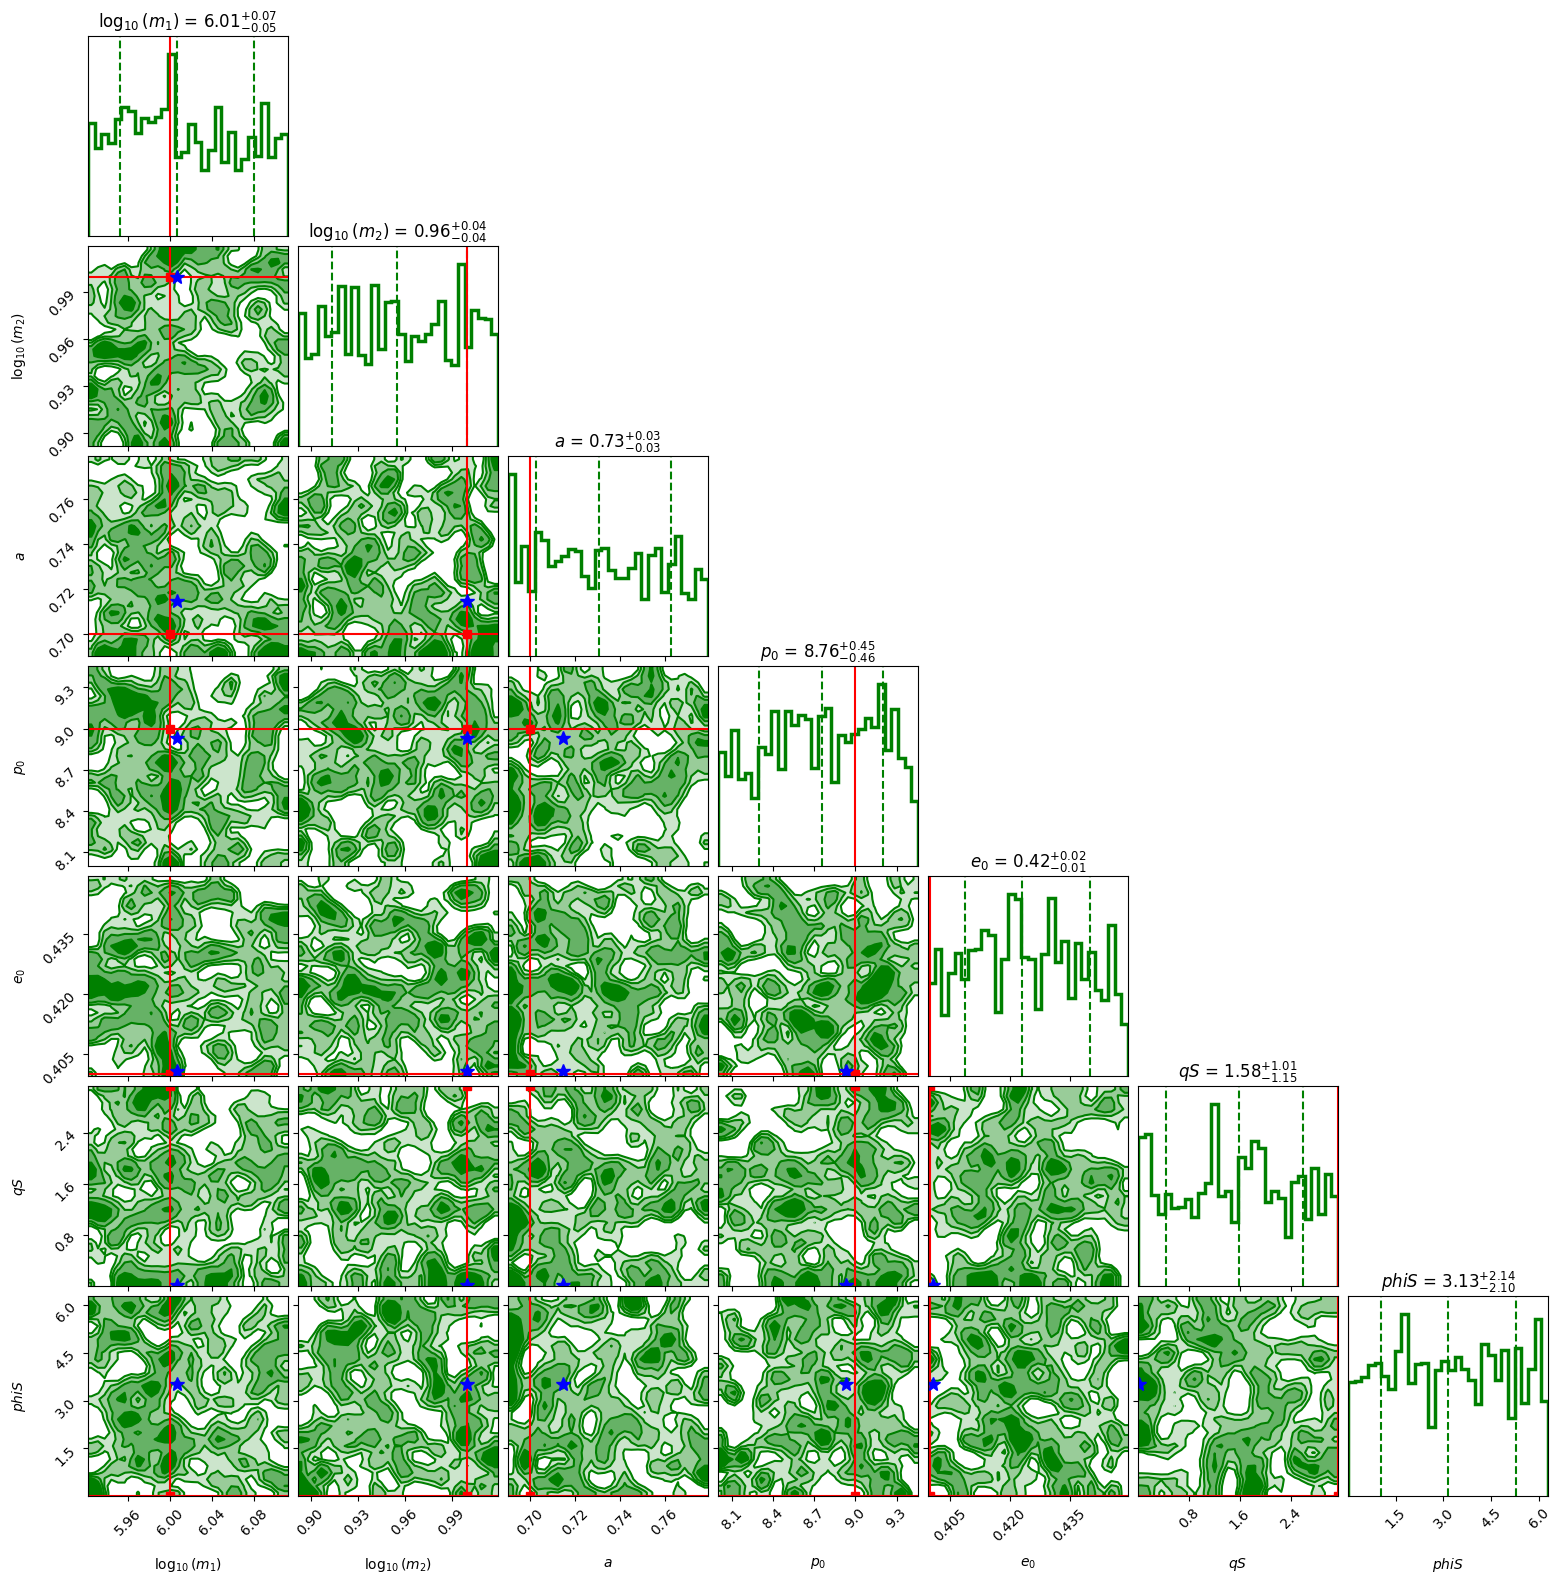

In [11]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$qS$', r'$phiS$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




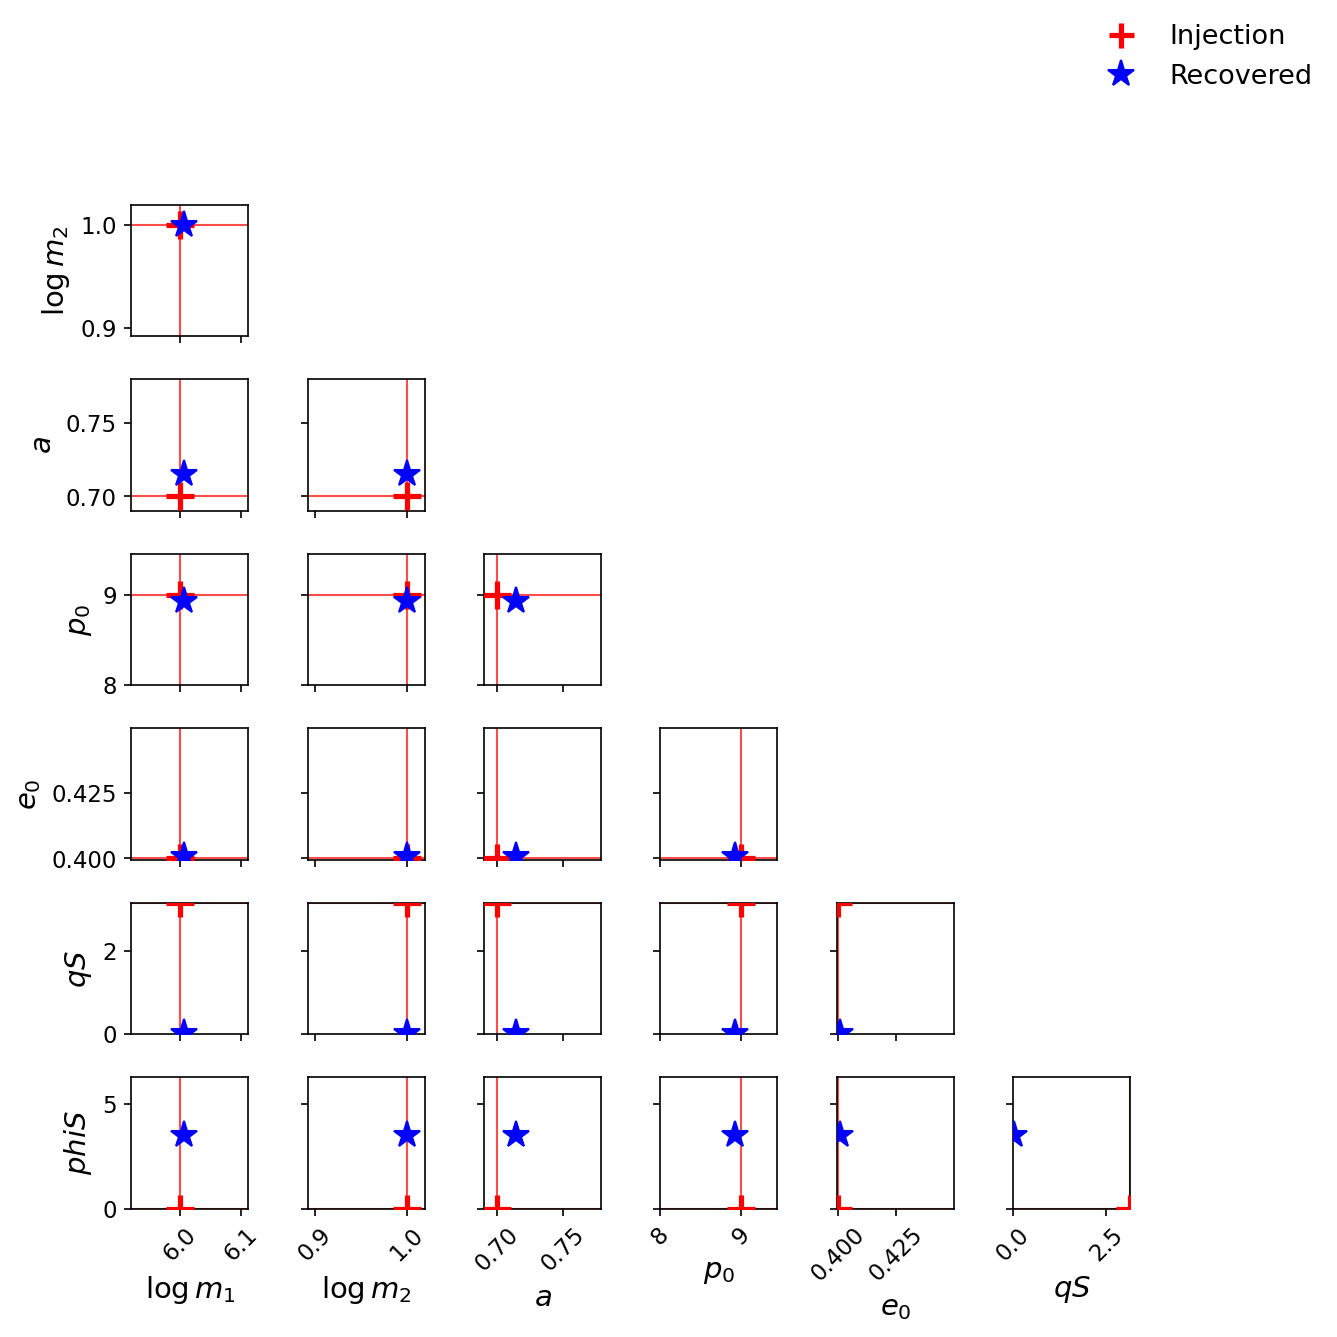

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

In [13]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_pts = prior_transform(proc_pt[0][top10_idx])


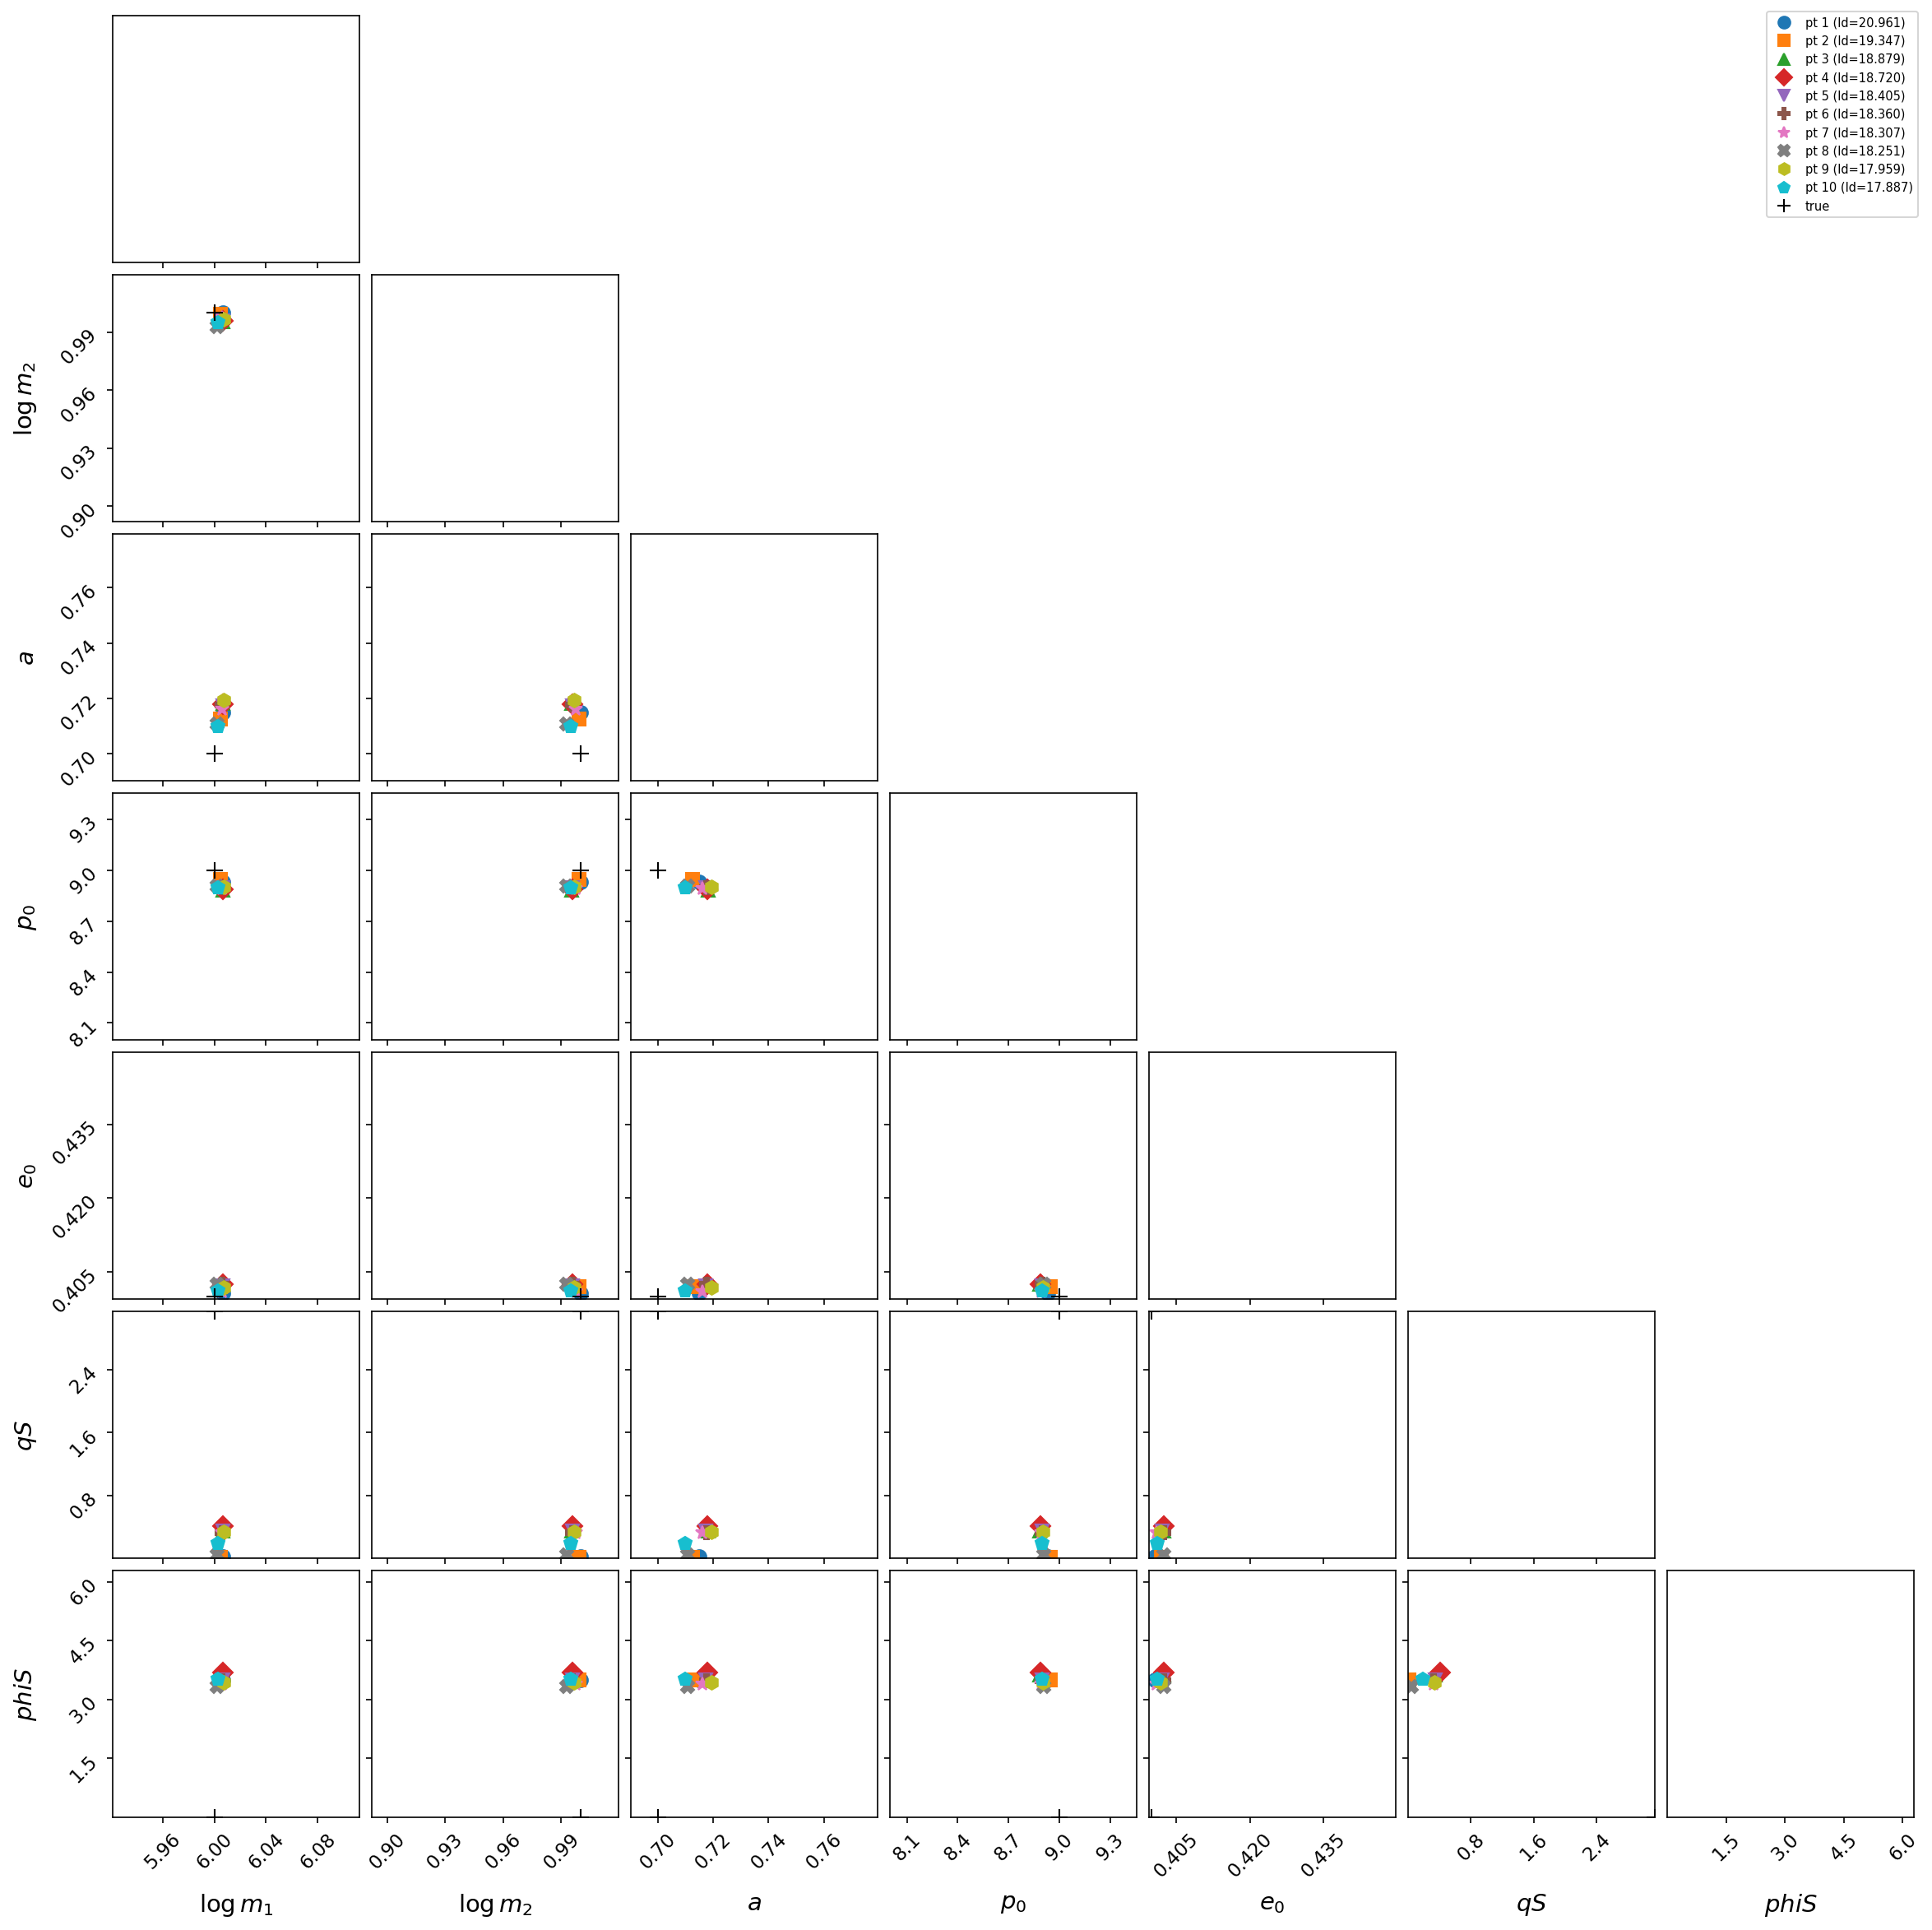

In [14]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [param_true]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=param_ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([param_true]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(param_ranges[col])
        if col < row:
            axes[row, col].set_ylim(param_ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

# connection plot

In [15]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[6.00642793, 0.99997911, 0.71484013, 8.93267973, 0.40074913,
        0.01632843, 3.50714766]])

In [16]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [17]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [18]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


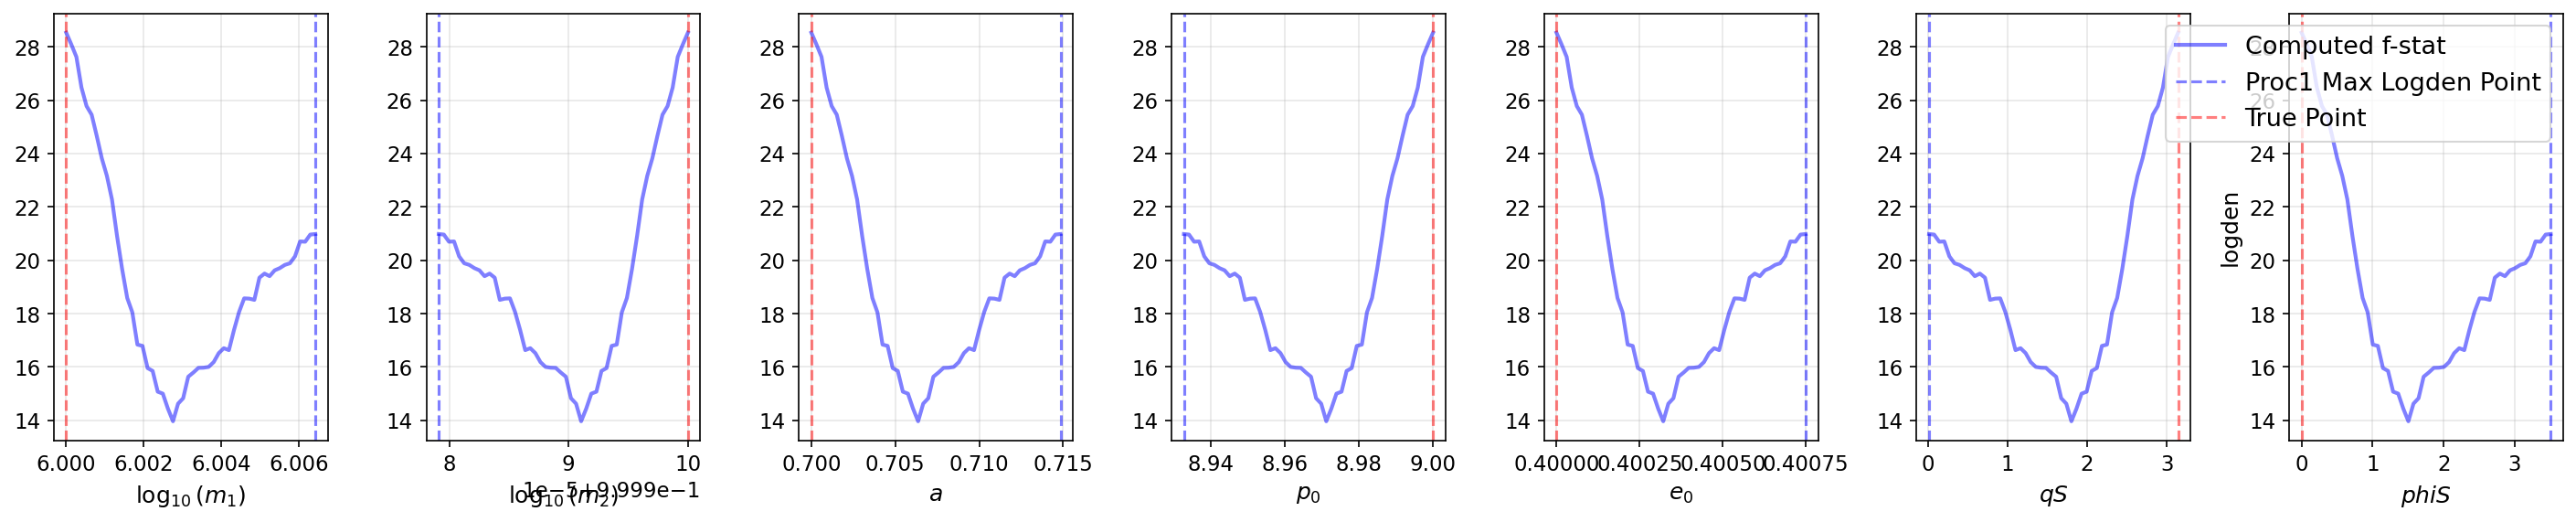

In [19]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [20]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [21]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [22]:
logden_tm = log_density(line_points_logm1.T)


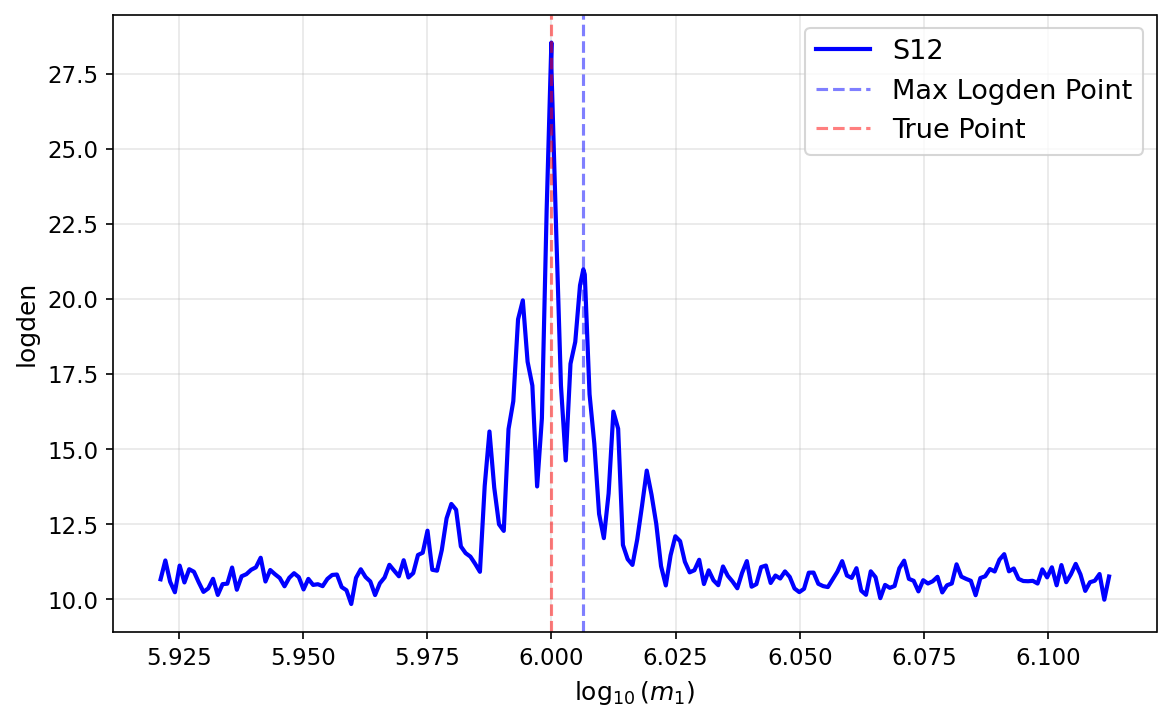

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S12')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()